# Hill Radius and Gravitational Dominance in the Solar System

This notebook presents a simplified computational analysis of gravitational dominance around selected Solar System bodies using Hill-radius scaling.

The study compares Earth, Mars, Jupiter, and the asteroid 101955 Bennu to examine how relative gravitational influence changes with distance across systems with very different masses and orbital scales.

The model evaluates the ratio between the gravitational force exerted by each body and that exerted by the Sun as a function of normalized distance. This provides a first-order approximation of the transition between body-dominated and solar-dominated dynamical regimes.

Distances are expressed in units of the Hill radius in order to enable direct comparison between systems that differ by many orders of magnitude in size and mass.

Author: Ömür Çarboğa

Method: Python numerical simulation using Newtonian gravitational scaling

Year: 2026

## Method Overview

"""
The model estimates gravitational dominance by comparing the gravitational
force exerted by a celestial body with the gravitational force exerted by
the Sun at the same particle location.

For each system, the stability ratio is defined as:

    S = F_body / F_solar

where F_body is the gravitational force from the body and F_solar is the
gravitational force from the Sun.

Distances are expressed as fractions of the Hill radius, allowing systems
with very different masses and orbital scales to be compared within a
common normalized framework.

The simulation evaluates the stability ratio across a continuous range of
normalized distances and visualizes how gravitational dominance changes
with position for each body.

Units used in this simulation:

- Distance: meters
- Mass: kilograms
- Hill radius: meters
- Plot axis: Hill-radius units (r / R_H)
"""

### Gravitational Force Ratio

"""
The stability metric used in this simulation is the ratio between the
gravitational force exerted by the secondary body and the gravitational
force exerted by the Sun at the same particle location.

The gravitational force is calculated using Newton's law of universal
gravitation:

    F = G M / r^2

where G is the gravitational constant, M is the mass of the attracting
body, and r is the distance between the body and the particle.

Using this relation, the dimensionless stability ratio is defined as:

    S = (G M_body / r_body^2) / (G M_sun / r_sun^2)

where:
- M_body is the mass of the secondary body,
- r_body is the particle distance from the body,
- M_sun is the mass of the Sun,
- r_sun is the particle distance from the Sun.

When S > 1, the gravitational influence of the secondary body exceeds
that of the Sun. When S < 1, solar gravity dominates the motion of the
particle.
"""

In [1]:
import numpy as np
import matplotlib.pyplot as plt

"""
PHYSICAL ASSUMPTIONS

1. The solar gravitational force is treated as approximately constant
   across the Hill sphere.

2. This approximation assumes that the particle distance from the
   secondary body (r) is much smaller than the orbital radius of the
   body around the Sun (a), such that:

       r << a

3. Under this assumption, the particle–Sun distance is approximated
   as the orbital radius a, and the solar gravitational force becomes:

       F_solar = G * M_sun / a^2

4. This represents a first-order approximation appropriate for
   Hill-radius scaling analysis within the local gravitational region
   of the secondary body.

5. A more precise treatment would replace a with (a ± r), allowing
   the particle–Sun distance to vary across the system. However, this
   correction is expected to produce only minor deviations within the
   normalized Hill-radius framework used in this study.
"""

"""
MODEL DESCRIPTION

This simulation evaluates gravitational dominance by comparing the
gravitational force exerted by a secondary body with the gravitational
force exerted by the Sun at the same particle location.

The model:
- Computes instantaneous gravitational force ratios
- Uses Hill-radius normalization
- Evaluates gravitational dominance as a function of distance
- Does NOT simulate orbital trajectories
- Does NOT include time evolution
- Does NOT solve the restricted three-body problem

Therefore, the results represent transitions between body-dominated
and solar-dominated gravitational regimes rather than exact orbital
stability boundaries.
"""

'\nMODEL DESCRIPTION\n\nThis simulation evaluates gravitational dominance by comparing the\ngravitational force exerted by a secondary body with the gravitational\nforce exerted by the Sun at the same particle location.\n\nThe model:\n- Computes instantaneous gravitational force ratios\n- Uses Hill-radius normalization\n- Evaluates gravitational dominance as a function of distance\n- Does NOT simulate orbital trajectories\n- Does NOT include time evolution\n- Does NOT solve the restricted three-body problem\n\nTherefore, the results represent transitions between body-dominated\nand solar-dominated gravitational regimes rather than exact orbital\nstability boundaries.\n'

## Hill Radius Function

In [2]:
def hill_radius(a, m, M):
    """
    Calculate the Hill radius of a celestial body.

    The Hill radius defines the approximate region within which the
    gravitational influence of a secondary body dominates over the
    tidal influence of the Sun.

    It is given by:

        R_H = a * (m / (3M))^(1/3)

    where:
    - a is the orbital radius of the body around the Sun,
    - m is the mass of the secondary body,
    - M is the mass of the Sun.

    Parameters
    ----------
    a : float
        Orbital distance from the Sun (m)

    m : float
        Mass of the secondary body (kg)

    M : float
        Mass of the Sun (kg)

    Returns
    -------
    float
        Hill radius (m)
    """

    return a * (m / (3 * M)) ** (1 / 3)

### Hill Radius Definition

"""
The Hill radius defines the approximate region around a celestial body
within which its gravitational influence dominates over the tidal
perturbations of the Sun.

It is estimated using:

    R_H = a * (m / (3M))^(1/3)

where:

- a : orbital semi-major axis of the body
- m : mass of the secondary body
- M : mass of the Sun

The Hill radius provides a characteristic gravitational scale in
celestial mechanics and is commonly used to estimate the region in
which nearby particles or satellites may remain gravitationally bound
to a planetary body.
"""

## Physical Constants

In [3]:
# Physical Constants

G = 6.67430e-11      # Gravitational constant (m^3 kg^-1 s^-2)
M_sun = 1.989e30     # Mass of the Sun (kg)


# Planetary Data

jupiter_mass = 1.898e27     # Jupiter mass (kg)
jupiter_orbit = 7.78e11     # Jupiter orbital radius (m)

earth_mass = 5.972e24       # Earth mass (kg)
earth_orbit = 1.496e11      # Earth orbital radius (m)

mars_mass = 6.39e23         # Mars mass (kg)
mars_orbit = 2.279e11       # Mars orbital radius (m)


# Asteroid Data

bennu_mass = 7.8e10         # 101955 Bennu mass (kg)
bennu_orbit = 1.68e11       # 101955 Bennu orbital radius (m)


# MODEL NOTE
#
# 101955 Bennu has an extremely small mass compared to planetary bodies.
# Consequently, its Hill radius and gravitational dominance region are
# expected to be very limited.
#
# Including Bennu in the analysis allows the model to examine how
# gravitational dominance behavior changes across systems spanning many
# orders of magnitude in mass.

## Celestial Body Data

In [4]:
bodies = {
    "Jupiter": (
        jupiter_mass,
        jupiter_orbit,
        hill_radius(jupiter_orbit, jupiter_mass, M_sun)
    ),

    "Earth": (
        earth_mass,
        earth_orbit,
        hill_radius(earth_orbit, earth_mass, M_sun)
    ),

    "Mars": (
        mars_mass,
        mars_orbit,
        hill_radius(mars_orbit, mars_mass, M_sun)
    ),

    "Bennu": (
        bennu_mass,
        bennu_orbit,
        hill_radius(bennu_orbit, bennu_mass, M_sun)
    )
}

## Hill Radius Calculations

In [5]:
# Compute Hill Radii

jupiter_hill = hill_radius(jupiter_orbit, jupiter_mass, M_sun)
earth_hill   = hill_radius(earth_orbit, earth_mass, M_sun)
mars_hill    = hill_radius(mars_orbit, mars_mass, M_sun)
bennu_hill   = hill_radius(bennu_orbit, bennu_mass, M_sun)


# Display Results

print(f"Jupiter Hill Radius: {jupiter_hill:.2e} m")
print(f"Earth Hill Radius:   {earth_hill:.2e} m")
print(f"Mars Hill Radius:    {mars_hill:.2e} m")
print(f"Bennu Hill Radius:   {bennu_hill:.2e} m")

Jupiter Hill Radius: 5.31e+10 m
Earth Hill Radius:   1.50e+09 m
Mars Hill Radius:    1.08e+09 m
Bennu Hill Radius:   3.96e+04 m


### Interpretation

"""
The calculated Hill radii represent the approximate spatial extent over which each body maintains local gravitational dominance relative to the Sun.

More massive bodies possess substantially larger Hill spheres, allowing them to retain satellites and exert gravitational influence over a wider surrounding region. In contrast, low-mass bodies such as 101955 Bennu exhibit extremely small Hill radii, reflecting their comparatively weak gravitational influence.

These differences span several orders of magnitude and illustrate how gravitational dominance depends strongly on both body mass and orbital distance from the Sun.
"""

## Hill Radius Scale Comparison

"""
To illustrate the large variation in gravitational influence across different Solar System bodies, the Hill radius of each system is compared directly.

This comparison demonstrates how massive planetary bodies possess substantially larger regions of gravitational dominance than low-mass objects such as the asteroid 101955 Bennu.

Because the Hill radius depends on both body mass and orbital distance, the resulting scales span several orders of magnitude across the systems included in this study.
"""

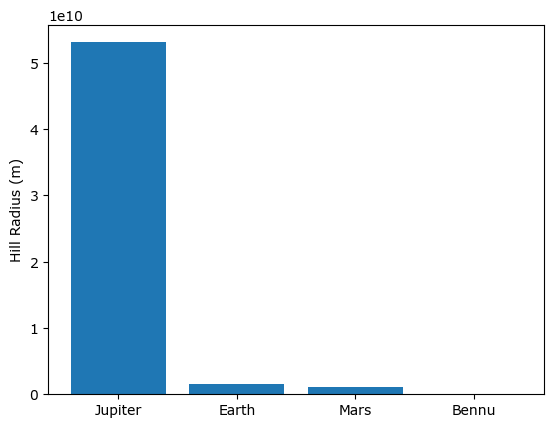

In [6]:
objects = ["Jupiter", "Earth", "Mars", "Bennu"]

hill_values = [
    jupiter_hill,
    earth_hill,
    mars_hill,
    bennu_hill
]

plt.figure()

plt.bar(objects, hill_values)

plt.ylabel("Hill Radius (m)")

plt.savefig("hill_radius.png")

plt.show()

### Interpretation

The figure shows that Jupiter possesses the largest Hill sphere among the studied bodies, reflecting its substantially greater mass and extended gravitational influence.

Earth and Mars exhibit smaller Hill spheres, with Mars maintaining a more limited gravitational region due to its lower mass.

In contrast, the asteroid 101955 Bennu has an extremely small Hill radius, illustrating the weak gravitational influence of low-mass bodies compared to planetary systems.

## Orbital Stability Analysis

In [7]:
# Gravity Ratio Function
#
# This function computes the dimensionless stability ratio between the
# gravitational force exerted by a secondary body and the gravitational
# force exerted by the Sun at the same particle location.
#
# S > 1   → local gravitational dominance of the secondary body
# S ≈ 1   → approximate transition between body-dominated and
#           solar-dominated regimes
# S < 1   → solar gravity dominates
#
# In the numerical analysis, a small tolerance is used when identifying
# transition regions because floating-point calculations rarely produce
# values exactly equal to 1.

def stability_ratio(r, m_planet, M_sun, a_planet, G):
    """
    Compute the gravitational stability ratio at distance r.

    The ratio is defined as:

        S = F_planet / F_solar

    using Newtonian gravitational acceleration.

    Parameters
    ----------
    r : float
        Distance from the secondary body (m)

    m_planet : float
        Mass of the secondary body (kg)

    M_sun : float
        Mass of the Sun (kg)

    a_planet : float
        Orbital distance of the body from the Sun (m)

    G : float
        Gravitational constant

    Returns
    -------
    float
        Dimensionless gravitational stability ratio
    """

    planet_gravity = G * m_planet / r**2
    solar_gravity = G * M_sun / a_planet**2

    return planet_gravity / solar_gravity

## Model Assumptions

This computational model evaluates gravitational dominance within the Hill-radius framework under several simplifying assumptions:

- The Sun–body system is treated as an isolated two-body system
- Perturbations from additional planetary bodies are neglected
- Test particles are assumed to have negligible mass
- Circular orbits are assumed for all systems
- Gravitational influence is evaluated using instantaneous force ratios

These assumptions allow a simplified first-order analysis of the transition between body-dominated and solar-dominated gravitational regimes.

## Test Distances

In [8]:
x = np.linspace(0.01, 2.0, 2000)

### Radial Sampling Domain

The normalized radial coordinate x represents distance in units of the Hill radius (r / R_H).

Distances are sampled from 0.01 to 2.0 Hill radii using 2000 evenly spaced points. This interval spans both strongly body-dominated regions and regions in which solar gravitational influence becomes increasingly significant.

Sampling across this normalized domain allows the simulation to evaluate how the gravitational stability ratio varies as a function of scaled distance from each body.

### Simulation Method

"""
This simulation analyzes gravitational dominance around selected Solar
System bodies using the Hill-radius framework.

The model compares the gravitational force exerted by a secondary body
with the gravitational force exerted by the Sun at different radial
distances.

The dimensionless stability ratio is defined as:

    S = F_body / F_solar

Distances are expressed in units of the Hill radius (r / R_H). The
transition region is identified where the stability ratio approaches
unity, corresponding to comparable gravitational influence from the
secondary body and the Sun.

The gravity-ratio threshold used in this simulation represents a
simplified indicator of gravitational dominance and should not be
interpreted as an exact orbital stability boundary. True orbital
stability depends on the full dynamical behavior of the Restricted
Three-Body Problem.

Bodies analyzed in this simulation:

- Jupiter
- Earth
- Mars
- Asteroid 101955 Bennu
"""

In [9]:
# MODEL LIMITATION NOTE
#
# This simulation evaluates the ratio between the gravitational influence
# of the Sun and that of a secondary body.
#
# The resulting stability ratio is used as a simplified indicator of
# gravitational dominance within the Hill-radius framework.
#
# The model:
# - Computes instantaneous force ratios
# - Does NOT simulate orbital trajectories
# - Does NOT include time evolution
# - Does NOT solve the Restricted Three-Body Problem
#
# Consequently, the results represent approximate transitions between
# body-dominated and solar-dominated gravitational regimes rather than
# exact orbital stability boundaries.

results = {}

for name, (mass, orbit, hill) in bodies.items():

    # Convert normalized Hill-radius coordinates to physical distance
    r = x * hill

    ratio = stability_ratio(
        r,
        mass,
        M_sun,
        orbit,
        G
    )

    results[name] = ratio

### Gravitational Dominance Transition Detection

To estimate the transition between body-dominated and solar-dominated
gravitational regimes, the simulation identifies the radial distance at
which the gravitational stability ratio approaches unity.

This condition is defined as:

    F_body / F_solar = 1

At this location, the gravitational contributions from the secondary
body and the Sun are approximately equal. Beyond this transition region,
solar gravitational influence becomes increasingly dominant.

The algorithm searches for the first location at which the computed
stability ratio crosses unity. A small numerical tolerance is applied
to reduce sensitivity to floating-point precision effects.

In [10]:
# Transition Detection Function
#
# This function estimates the normalized radial distance at which the
# gravitational stability ratio crosses unity, corresponding to the
# approximate transition between body-dominated and solar-dominated
# gravitational regimes.

def find_dominance_transition_radius(x, ratios):
    """
    Estimate the transition location where the stability ratio
    approaches unity.

    A small numerical tolerance is included to reduce sensitivity
    to floating-point precision effects.

    Parameters
    ----------
    x : ndarray
        Normalized radial distances in Hill-radius units

    ratios : ndarray
        Computed gravitational stability ratios

    Returns
    -------
    float or None
        Approximate transition distance in Hill-radius units.
        Returns None if no transition is detected within the
        sampled domain.
    """

    tolerance = 1e-6

    for i in range(1, len(ratios)):

        if (
            ratios[i] <= 1 + tolerance
            and ratios[i - 1] > 1 + tolerance
        ):
            return x[i]

    return None

In [11]:
# Compute Gravitational Dominance Transition Points
#
# For each system, the algorithm identifies the approximate normalized
# radial distance at which the gravitational stability ratio crosses
# unity.

transition_points = {}

for name, ratios in results.items():

    transition = find_dominance_transition_radius(x, ratios)

    transition_points[name] = transition

In [12]:
# Display Transition Points

for body, transition in transition_points.items():

    if transition is None:

        print(
            f"{body}: No transition point detected "
            f"within the sampled range"
        )

    else:

        print(
            f"{body} transition point ≈ "
            f"{round(transition, 3)} Hill radii"
        )

Jupiter transition point ≈ 0.453 Hill radii
Earth transition point ≈ 0.173 Hill radii
Mars transition point ≈ 0.12 Hill radii
Bennu: No transition point detected within the sampled range


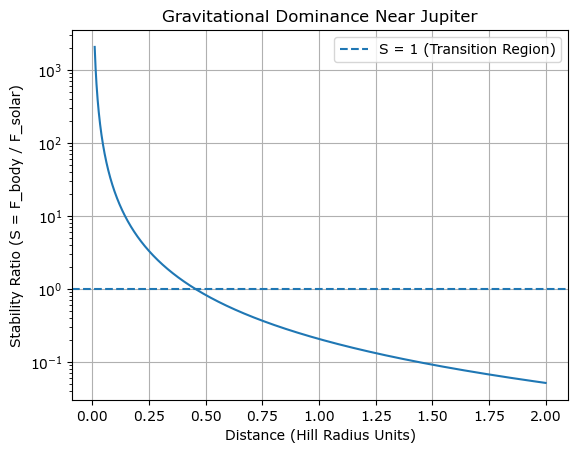

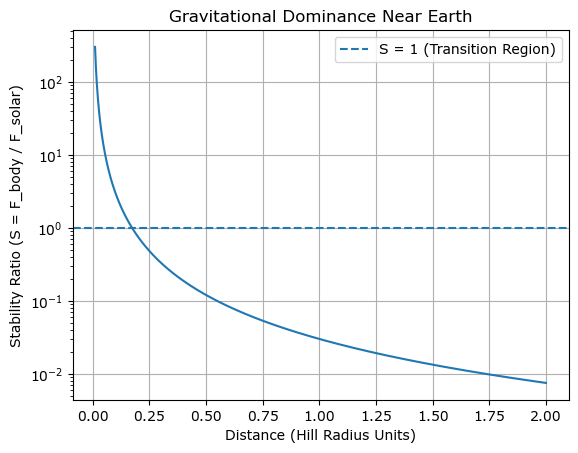

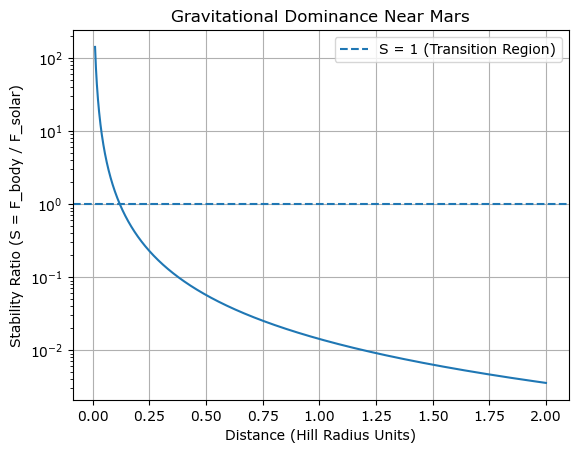

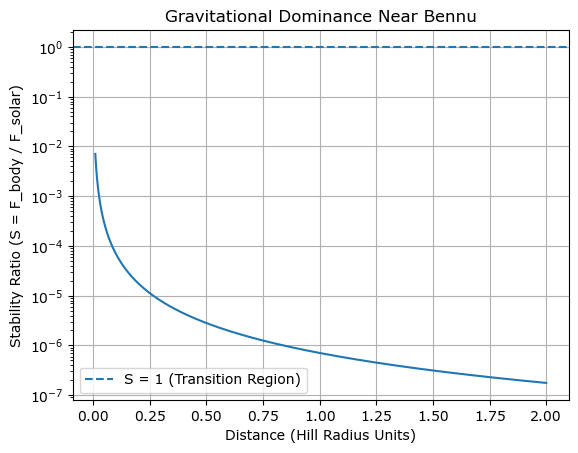

In [13]:
import matplotlib.pyplot as plt

# Generate Gravitational Dominance Profiles

for name, ratios in results.items():

    plt.figure()

    plt.plot(x, ratios)

    # Transition threshold (S = 1)
    plt.axhline(
        1,
        linestyle="--",
        label="S = 1 (Transition Region)"
    )

    # Logarithmic scaling improves visibility across
    # multiple orders of magnitude
    plt.yscale("log")

    plt.xlabel("Distance (Hill Radius Units)")
    plt.ylabel("Stability Ratio (S = F_body / F_solar)")

    plt.title(f"Gravitational Dominance Near {name}")

    plt.grid(True)
    plt.legend()

    plt.savefig(f"{name}_stability_plot.png", dpi=300)

    plt.show()

In [14]:
import pandas as pd

# Construct Summary Table

rows = []

for name, (mass, orbit, hill) in bodies.items():

    rows.append({
        "Body": name,
        "Hill Radius (m)": hill,
        "Hill Radius (km)": hill / 1000
    })

# Create DataFrame

df = pd.DataFrame(rows)

# Start indexing from 1 for presentation clarity

df.index = df.index + 1
df.index.name = "No."

df

,Body,Hill Radius (m),Hill Radius (km)
No.,,,
1,Jupiter,5.310796e+10,5.310796e+07
2,Earth,1.496418e+09,1.496418e+06
3,Mars,1.082246e+09,1.082246e+06
4,Bennu,3.957511e+04,3.957511e+01


## Stability Comparison

The figure below compares the gravitational dominance profiles of each body as a function of normalized distance measured in Hill-radius units.

The vertical axis represents the dimensionless stability ratio:

    S = F_body / F_solar

Values greater than unity indicate that the gravitational influence of the secondary body exceeds that of the Sun, corresponding to locally body-dominated gravitational regimes where satellite retention becomes more favorable.

The dashed reference lines indicate:

- x = 1 Hill radius
- S = 1 (equal gravitational influence)

This comparison illustrates the substantial differences in gravitational dominance between massive planetary bodies and low-mass objects such as the asteroid 101955 Bennu.

## Comparative Gravitational Dominance Profiles

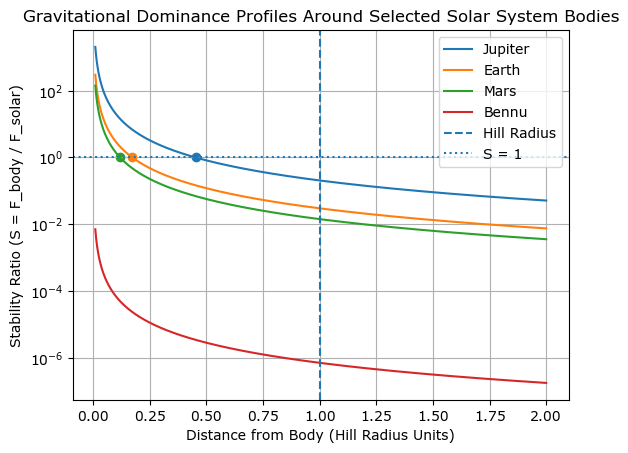

In [15]:
plt.figure()

for name, ratios in results.items():

    plt.plot(x, ratios, label=name)

for body, transition in transition_points.items():

    if transition is not None:

        plt.scatter(transition, 1)

plt.axvline(1, linestyle="--", label="Hill Radius")
plt.axhline(1, linestyle=":", label="S = 1")

plt.yscale("log")

plt.xlabel("Distance from Body (Hill Radius Units)")
plt.ylabel("Stability Ratio (S = F_body / F_solar)")

plt.title(
    "Gravitational Dominance Profiles Around "
    "Selected Solar System Bodies"
)

plt.legend()
plt.grid(True)

plt.savefig("comparative_behaviour.png")

plt.show()

### Stability Threshold Visualization

The horizontal dotted reference line corresponds to the condition:

    S = 1

At this threshold, the gravitational influence of the secondary body and the Sun are approximately equal. Values above unity indicate locally body-dominated gravitational regimes, while values below unity indicate increasing solar gravitational dominance.

The circular markers indicate the approximate transition locations at which the computed stability ratio approaches unity for each system within the sampled domain.

## Quantitative Results

The table below summarizes the key numerical results produced by the computational model, including Hill radius size and the detected stability boundary for each body.

In [16]:
# Transition Summary Table

print(
    "Body | Hill Radius (m) | "
    "Transition Distance (R_H) | Transition Distance (m)"
)

print("----------------------------------------------------------------")

for name, (mass, orbit, hill) in bodies.items():

    hill_m = hill

    transition_hr = transition_points[name]

    if transition_hr is not None:

        transition_m = transition_hr * hill_m

        print(
            f"{name} | "
            f"{round(hill_m, 2)} | "
            f"{round(transition_hr, 3)} | "
            f"{round(transition_m, 2)}"
        )

    else:

        print(
            f"{name} | "
            f"{round(hill_m, 2)} | "
            f"No transition detected within 2 R_H | "
            f"No transition detected within 2 R_H"
        )

Body | Hill Radius (m) | Transition Distance (R_H) | Transition Distance (m)
----------------------------------------------------------------
Jupiter | 53107964189.29 | 0.453 | 24057721806.89
Earth | 1496417737.09 | 0.173 | 259271777.51
Mars | 1082245857.02 | 0.12 | 129333523.15
Bennu | 39575.11 | No transition detected within 2 R_H | No transition detected within 2 R_H


### Interpretation of Bennu Results

The asteroid 101955 Bennu possesses an extremely small mass compared with planetary bodies such as Earth, Mars, and Jupiter Consequently, solar gravitational influence remains dominant across most of the sampled domain surrounding the asteroid. As a result, the computed stability ratio rarely exceeds unity, and no clear transition between body-dominated and solar-dominated regimes appears within the evaluated interval. Within the sampled range (0.01–2.0 Hill radii), the stability ratio does not cross the threshold condition:

    S = 1

Therefore, the transition-detection algorithm does not identify a gravitational dominance transition for Bennu within the analyzed domain. This result illustrates how gravitational dominance regions contract rapidly for extremely low-mass bodies.

## Comparison with Real Satellite Systems

The simulation results are broadly consistent with the observed structure of natural satellite systems throughout the Solar System.

Large planetary systems such as Jupiter possess extensive regions of local gravitational dominance, enabling the long-term retention of multiple satellites. The Galilean moons, for example, orbit well inside Jupiter's Hill sphere, where Jovian gravity strongly exceeds solar gravitational influence.

Similarly, the major moons of Earth and Mars also reside within regions where planetary gravitational effects remain dominant relative to solar perturbations.

The numerical results indicate that the transition between body-dominated and solar-dominated gravitational regimes generally occurs within a fraction of the Hill radius rather than precisely at the Hill-radius boundary itself. This behavior is consistent with the fact that stable satellite systems are typically concentrated well inside the formal Hill sphere.

In contrast, extremely low-mass bodies such as the asteroid 101955 Bennu possess only very limited regions of gravitational dominance. Consequently, small bodies are significantly less capable of retaining stable satellite systems over extended timescales.

Although simplified, the model reproduces the broader physical trend observed across real Solar System systems: increasing body mass leads to substantially larger and more persistent regions of gravitational control.

## Discussion

The results demonstrate the strong dependence of gravitational dominance on body mass across a wide range of Solar System objects. Massive planets maintain extensive regions in which their gravitational influence exceeds that of the Sun, enabling the persistence of complex satellite systems.

Among the analyzed bodies, Jupiter exhibits the largest gravitational dominance region due to its exceptionally large mass and correspondingly large Hill radius. The simulation indicates that Jovian gravity remains dominant across a substantially wider normalized region than for the terrestrial planets. This extended gravitational domain is consistent with Jupiter’s ability to maintain a large and dynamically complex satellite system.

Earth and Mars also exhibit significant regions of local gravitational dominance, although their transition distances occur at smaller fractions of the Hill radius compared with Jupiter. These results are consistent with the existence of stable natural satellites around terrestrial planets.

In contrast, the asteroid 101955 Bennu possesses an extremely limited region of gravitational dominance. Across most of the sampled domain, solar gravitational influence remains dominant. This behavior illustrates why long-term satellite retention becomes increasingly difficult for very low-mass bodies.

Overall, the comparison demonstrates how gravitational scaling shapes the local dynamical environments surrounding planetary bodies and provides a useful normalized framework for comparing gravitational dominance across systems with very different masses and orbital scales.

However, the Hill radius should be interpreted as an approximate gravitational scaling parameter rather than an exact orbital stability boundary. True orbital stability in a three-body system depends on long-term dynamical evolution and cannot be fully determined using instantaneous gravitational force ratios alone. 

## Model Limitations

This analysis uses a simplified gravitational force-ratio framework to approximate transitions between body-dominated and solar-dominated gravitational regimes near the Hill radius.

The model evaluates instantaneous gravitational influence and does not perform full orbital integrations or solve the Restricted Three-Body Problem. Consequently, the identified transition locations should be interpreted as approximate indicators of gravitational dominance rather than exact dynamical stability boundaries.

Additional simplifications include:
- neglecting perturbations from other planetary bodies,
- assuming circular orbits,
- and treating test particles as massless.

More advanced analyses would require numerical N-body simulations that track the long-term dynamical evolution of particle trajectories.

## Implications for Spacecraft Dynamics

Understanding gravitational dominance regions is important in spacecraft trajectory analysis, mission design, and orbital operations throughout the Solar System.

Spacecraft operating near planets, moons, or small bodies experience a continuous competition between local gravitational attraction and solar gravitational perturbations. The extent of a body's gravitational dominance region therefore plays a major role in determining whether stable or quasi-stable trajectories can be maintained.

Within the Hill sphere of a massive planet, spacecraft and natural satellites can remain gravitationally bound over extended timescales. Large Hill radii also enable the existence of complex multi-satellite systems and support a wide range of orbital configurations used in planetary exploration missions.

In contrast, small bodies such as asteroids possess extremely limited regions of gravitational dominance. Near these objects, solar gravitational influence remains significant even at relatively short distances from the surface. As a result, spacecraft dynamics near asteroids are often highly sensitive to perturbations and may require continuous trajectory correction or station-keeping maneuvers.

For this reason, many asteroid exploration missions utilize controlled proximity operations, hovering trajectories, or quasi-orbital motion instead of long-term stable Keplerian orbits. These dynamical constraints become increasingly important for navigation, landing operations, sample-return missions, and future small-body resource exploration.

## Conclusion

This computational analysis investigated how gravitational dominance varies with distance from a celestial body by comparing the local
gravitational influence of the body with that of the Sun within the Hill-radius framework.

Using normalized radial coordinates, the simulation demonstrates how gravitational dominance regions scale strongly with body mass and orbital configuration across a wide range of Solar System systems.

The terrestrial planets Earth and Mars exhibit clear transition regions where solar and planetary gravitational influence become comparable, occurring near approximately 0.17 R_H for Earth and 0.12 R_H for Mars within the adopted model framework.

In contrast, the asteroid 101955 Bennu exhibits extremely weak local gravitational dominance, with solar gravitational influence remaining significant throughout the sampled domain. This result illustrates the severe dynamical limitations associated with very low-mass bodies.

Jupiter represents the opposite extreme. Its exceptionally large mass produces a substantially larger Hill sphere and a much broader region of local gravitational dominance, consistent with the existence of an extensive and dynamically complex satellite system.

Overall, the results demonstrate how Hill-radius scaling provides a useful first-order framework for comparing gravitational environments across Solar System bodies with vastly different masses and orbital scales. Although simplified, the model reproduces several broad trends observed in real planetary and small-body systems and illustrates the fundamental role of gravitational scaling in celestial mechanics and spacecraft dynamics.